# Hierarchical Clustering

Hierarchical clustering groups samples based on expression similarity.

Steps:

1. Load the RNA-seq count matrix.
2. Log-transform and scale the counts.
3. Cluster samples using Euclidean distance and average linkage.
4. Plot the dendrogram.
5. Show the full expression heatmap.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from sklearn.preprocessing import StandardScaler


## Load Data

Genes are rows and samples are columns. The subtype label is stored in the sample name, before `_rep`.

In [2]:
url = "https://raw.githubusercontent.com/jimmyrouse/BSR/main/tumor_subtype_counts_5groups.csv"
local_file = Path("tumor_subtype_counts_5groups.csv")

if local_file.exists():
    df_counts = pd.read_csv(local_file)
else:
    df_counts = pd.read_csv(url)

df_counts.head()

,Gene,Normal_rep1,Normal_rep2,Normal_rep3,Normal_rep4,Normal_rep5,Basal_1_rep1,Basal_1_rep2,Basal_1_rep3,Basal_1_rep4,...,Classical_1_rep1,Classical_1_rep2,Classical_1_rep3,Classical_1_rep4,Classical_1_rep5,Classical_2_rep1,Classical_2_rep2,Classical_2_rep3,Classical_2_rep4,Classical_2_rep5
0,PRSS1,564,534,711,396,688,185,116,154,130,...,92,166,92,131,115,153,151,114,148,138
1,PRSS2,926,531,702,533,791,125,103,200,171,...,191,161,146,89,107,163,229,248,119,128
2,PRSS3,715,430,533,470,645,160,152,190,141,...,98,99,150,166,141,135,133,114,107,166
3,CPA1,602,682,565,543,412,210,156,186,130,...,181,183,243,166,135,295,113,99,131,288
4,CPA2,530,800,556,850,783,178,194,226,178,...,154,132,187,61,223,159,114,164,153,127


In [3]:
counts = df_counts.set_index("Gene")

labels = pd.Series(
    counts.columns.str.replace(r"_rep\d+$", "", regex=True),
    index=counts.columns,
    name="subtype",
)

print("Genes x samples:", counts.shape)
print(labels.value_counts())

counts.iloc[:8, :8]

Genes x samples: (260, 25)
Normal         5
Basal_1        5
Basal_2        5
Classical_1    5
Classical_2    5
Name: subtype, dtype: int64


,Normal_rep1,Normal_rep2,Normal_rep3,Normal_rep4,Normal_rep5,Basal_1_rep1,Basal_1_rep2,Basal_1_rep3
Gene,,,,,,,,
PRSS1,564,534,711,396,688,185,116,154
PRSS2,926,531,702,533,791,125,103,200
PRSS3,715,430,533,470,645,160,152,190
CPA1,602,682,565,543,412,210,156,186
CPA2,530,800,556,850,783,178,194,226
CPB1,707,658,607,642,391,115,152,138
CTRB1,659,760,682,639,568,161,105,166
CTRB2,875,573,416,533,489,166,271,131


## Transform Counts

RNA-seq count matrices are usually shown as genes x samples, so we keep that shape here.

First we use `log2(count + 1)`. Then we scale each gene across samples so clustering focuses on expression patterns instead of raw count size.

In [4]:
counts_log = np.log2(counts + 1)

counts_scaled = pd.DataFrame(
    StandardScaler().fit_transform(counts_log.T).T,
    index=counts_log.index,
    columns=counts_log.columns,
)

print("Genes x samples:", counts_scaled.shape)
counts_scaled.iloc[:8, :8]

Genes x samples: (260, 25)


,Normal_rep1,Normal_rep2,Normal_rep3,Normal_rep4,Normal_rep5,Basal_1_rep1,Basal_1_rep2,Basal_1_rep3
Gene,,,,,,,,
PRSS1,1.861255,1.772180,2.238806,1.285114,2.185195,0.047264,-0.709583,-0.250401
PRSS2,2.281367,1.470538,1.877497,1.476016,2.051552,-0.632589,-0.912776,0.049329
PRSS3,2.362392,1.471230,1.847463,1.627052,2.181761,-0.257648,-0.347131,0.042353
CPA1,1.883446,2.121485,1.762450,1.686698,1.160278,-0.122974,-0.687821,-0.353699
CPA2,1.414632,2.038059,1.487125,2.129884,2.005527,-0.234361,-0.104528,0.125903
CPB1,2.127657,2.013844,1.886022,1.974840,1.189515,-0.742797,-0.303470,-0.455754
CTRB1,1.886988,2.103291,1.939023,1.840244,1.661622,-0.246739,-0.891056,-0.200564
CTRB2,2.515997,1.813434,1.282373,1.693387,1.550476,-0.238455,0.572253,-0.629329


## Cluster Samples

The count matrix is genes x samples. Right before clustering, we transpose it so samples become rows.

We use:

- `euclidean` distance: straight-line distance between samples.
- `average` linkage: average distance between groups when clusters merge.

In [5]:
X_for_clustering = counts_scaled.T

Z = linkage(X_for_clustering, method="average", metric="euclidean")


## Cut The Tree Two Ways

There are two common ways to turn the dendrogram into final cluster labels:

1. `criterion="maxclust"`: ask for a target number of clusters.
2. `criterion="distance"`: cut the tree at a chosen cluster-distance height.

The first method is useful when you already know how many groups you want. The second method is useful when you want to cut the tree based on dendrogram height.

In [6]:
# Method 1: cut the tree into exactly 5 clusters.
clusters_maxclust = fcluster(Z, t=5, criterion="maxclust")

cluster_table_maxclust = pd.DataFrame({
    "sample": X_for_clustering.index,
    "subtype_from_name": labels.values,
    "cluster_maxclust": clusters_maxclust,
})

cluster_table_maxclust

,sample,subtype_from_name,cluster_maxclust
0,Normal_rep1,Normal,1
1,Normal_rep2,Normal,1
2,Normal_rep3,Normal,1
3,Normal_rep4,Normal,1
4,Normal_rep5,Normal,1
5,Basal_1_rep1,Basal_1,3
6,Basal_1_rep2,Basal_1,3
7,Basal_1_rep3,Basal_1,3
8,Basal_1_rep4,Basal_1,3
9,Basal_1_rep5,Basal_1,3


In [7]:
# Method 2: cut the tree at a distance threshold.
distance_cutoff = 15
clusters_by_distance = fcluster(Z, t=distance_cutoff, criterion="distance")

cluster_table_by_distance = pd.DataFrame({
    "sample": X_for_clustering.index,
    "subtype_from_name": labels.values,
    "cluster_by_distance": clusters_by_distance,
})

print("Number of clusters:", len(np.unique(clusters_by_distance)))
cluster_table_by_distance

Number of clusters: 5


,sample,subtype_from_name,cluster_by_distance
0,Normal_rep1,Normal,1
1,Normal_rep2,Normal,1
2,Normal_rep3,Normal,1
3,Normal_rep4,Normal,1
4,Normal_rep5,Normal,1
5,Basal_1_rep1,Basal_1,3
6,Basal_1_rep2,Basal_1,3
7,Basal_1_rep3,Basal_1,3
8,Basal_1_rep4,Basal_1,3
9,Basal_1_rep5,Basal_1,3


## Dendrogram

The dendrogram shows which samples merge together first. Samples that join at lower heights are more similar.

The dashed line shows the distance cutoff used by Method 2.

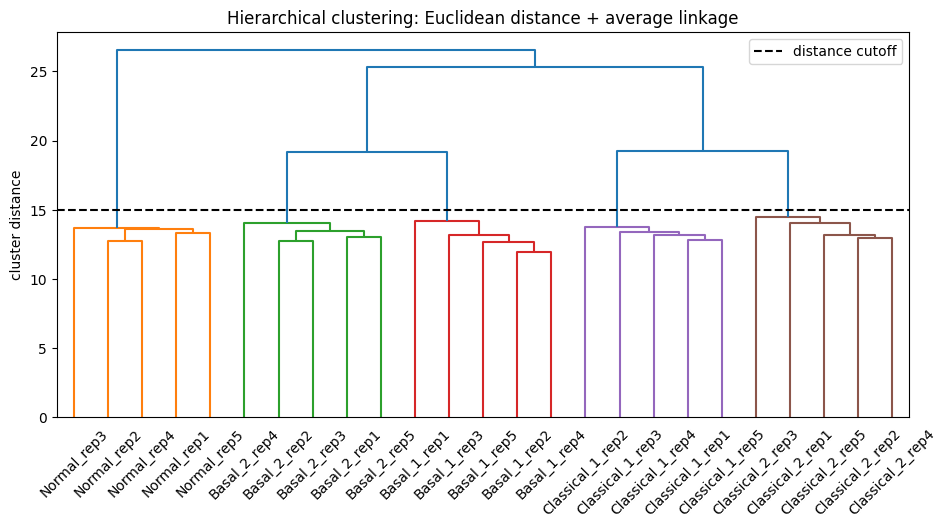

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))

dendrogram(Z, labels=X_for_clustering.index.tolist(), ax=ax, color_threshold=None)
ax.axhline(distance_cutoff, color="black", linestyle="--", linewidth=1.5, label="distance cutoff")
ax.set_title("Hierarchical clustering: Euclidean distance + average linkage")
ax.set_ylabel("cluster distance")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.show()

## Heatmap

The heatmap shows all genes. Columns are samples and rows are genes. Both samples and genes are clustered.

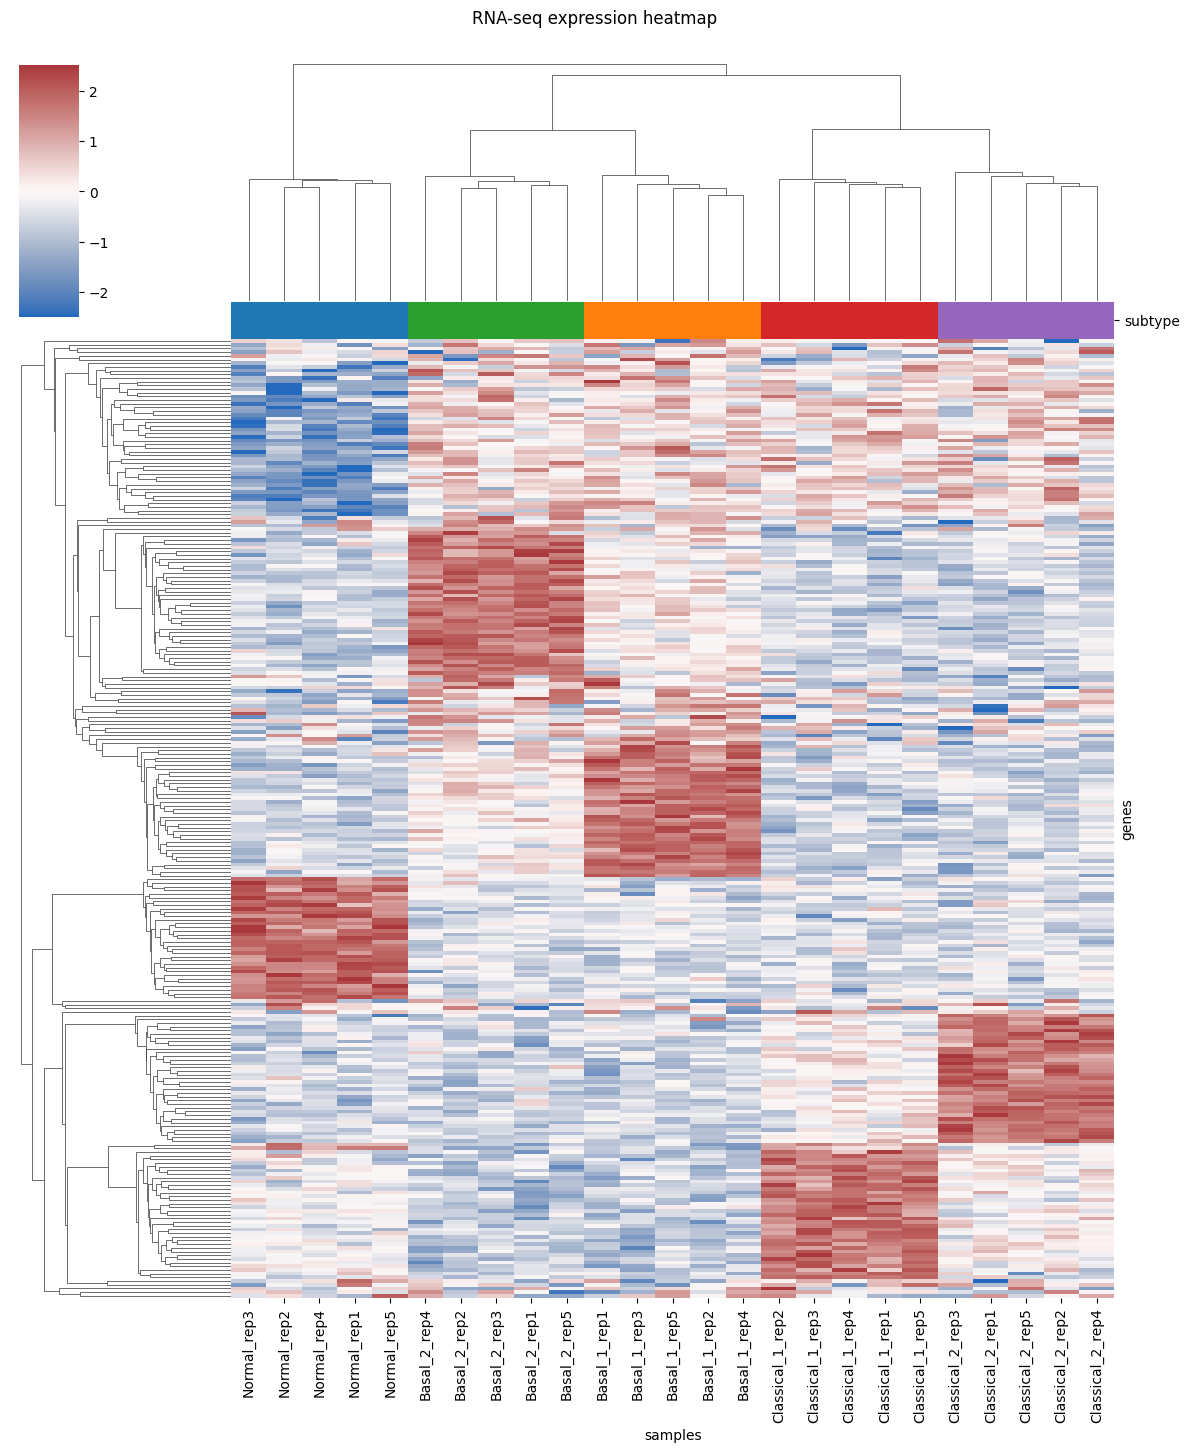

In [9]:
palette = dict(zip(labels.unique(), sns.color_palette("tab10", n_colors=labels.nunique())))
col_colors = labels.map(palette)

# counts_scaled is genes x samples.
# col_linkage=Z clusters the sample columns.
# row_cluster=True clusters the gene rows.
grid = sns.clustermap(
    counts_scaled,
    col_linkage=Z,
    row_cluster=True,
    col_colors=col_colors,
    cmap="vlag",
    center=0,
    vmin=-2.5,
    vmax=2.5,
    figsize=(12, 14),
    xticklabels=True,
    yticklabels=False,
)

grid.fig.suptitle("RNA-seq expression heatmap", y=1.02)
grid.ax_heatmap.set_xlabel("samples")
grid.ax_heatmap.set_ylabel("genes")
plt.show()